#### run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Set up and getting data

In [1]:
# !pip install xgboost
# !pip install imbalanced-learn
# !pip install catboost
# !pip install optuna
# !pip install torch
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
import random
import torch
import optuna
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
random.seed(35)
np.random.seed(35)

client = bigquery.Client()

def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [2]:
# Get features
sql = """
SELECT
    f.* EXCEPT (asdb_plan_key, post_mnths, first_prv_dt, last_prv_dt, index_dt)
    , e.* EXCEPT (individual_id)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features_v2` AS f
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_embeddings` AS e
        ON f.asdb_member_key = e.individual_id
WHERE 1=1
    AND NOT asdb_plan_key IN (33, 54)
    AND post_mnths >= 6
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape
#2,191,619 members who qualify per BQ
#1,875,523 have embeddings
#1,647,108 after we cut out too short of followup time

(1636185, 561)

In [3]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    asdb_member_key
    , acute_ip_flag
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_outcome_ip` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_og = client.query(sql).to_dataframe() 
outcome_og.shape

(1636179, 2)

### Data Preprocessing

#### Fill in zeros

In [4]:
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float
import re

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df_og.columns if re.match(emb_pattern ,col)]
df_og[emb_col] = df_og[emb_col].fillna(0)
for c in df_og.columns: 
    dt = df_og[c].dtype
    if is_integer(dt) or is_float(dt):
        df_og[c]=df_og[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df_og[c]= df_og[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)

#### One Hot Encode Categorical

In [5]:
#  0 := categorical, 1 := continuous, 2 := binary
nem_to_type = {
    'narc':2, 
    # 'otc_fills_yr2': 1,
    # 'otc_fills_yr1':1,  
    'COP':2, 
    'sleep_apnea':2, 
    'spinal_inj':2,
    'back':2,
    'substance':2,
    'ALC':2,
    'bipolar':2,
    'psychoses':2,
    'EDO':2, 
    'SCA':2, 
    'DIA':2, 
    'DEP':2, 
    'abdominal_pain':2, 
    'OST':2, 
    'AID':2, 
    'IDA':2, 
    'ANX':2, 
    'DEM':2, 
    'CYS':2, 
    'autoimmune':2, 
    'MOH':2, 
    'HEM':2, 
    'esrd':2, 
    'HepC':2, 
    'HYP':2, 
    'HYC':2, 
    'immune':2, 
    'intel_dsblty':2, 
    'meta_cancer':2, 
    'liver_dis':2, 
    'MSS':2, 
    'OBE':2, 
    'oud':2, 
    'liver_other':2, 
    'paralysis':2, 
    'PAR':2, 
    'PUD':0, 
    'hmd':2, 
    'PVD':2, 
    'CRO':2, 
    'AST':2, 
    'EPL':2, 
    'low_med_sev_ed_flag_yr2':2, 
    'med_high_sev_ed_flag_yr2':2, 
    'high_sev_ed_flag_yr2':2, 
    'acute_ip_flag_yr1':2, 
    'CHO':2,
    'burns':2, 
    'acute_ip_flag_yr2':2, 
    'cad':2, 
    'Cancer':2, 
    'ed_flag_yr2':2, 
    'high_sev_ed_flag_yr1':2, 
    'med_sev_ed_flag_yr2':2, 
    'AUT':2, 
    'med_high_sev_ed_flag_yr1':2, 
    'low_med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr1':2, 
    'CBD':2, 
    'CHF':2, 
    'CRF':2, 
    'VNA':2, 
    'CHD':2, 
    'ed_flag_yr1':2, 
    'med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr2':2, 
    'urbsubr':0, 
    'gender':0, # TODO: IF = M, 1 ELIF = F 0 ELSE NULL 
    'cms_prost_cancer_scrn':0, 
    'cms_hpv_scrn':0, 
    'cms_cvd_scrn':0, 
    'cms_lung_cancer_scrn':0, 
    'cms_pelvic':0,
    'coa_population_group':0, 
    'cms_pap':0, 
    'cms_t2d_scrn':0, 
    'cms_bone_scrn':0, 
    'cms_alc_scrn':0,
    'cms_ibt_cvd':0, 
    'cms_col_scrn':0,
    'index_dt':0, 
    'cms_ibt_obese':0, 
    'cms_flu_vax':0, 
    'cms_pneum_vax':0, 
    'cms_dep_scrn':0,
    'tenure_yr2':1, # either 
    'tenure_yr1':1, # either
    'cms_hepb_vax':0,
    'low_sev_ed_visits_yr2':0, # 7/2/24 removed
    'coa_population_category':0, 
    'cms_mam_scrn':0, # 7/2/24 removed
    'low_sev_ed_visits_yr1':1,
    'sum_acute_ip_admits_yr2':1,
    'sum_acute_ip_admits_yr1':1,
    'cms_tobacco':0,# 7/2/24 removed
    'low_med_sev_ed_visits_yr2':1, 
    'cms_t2d_train':0, # 7/2/24 removed
    'sum_preventable_yr2':1, 
    'cms_hepb_scrn':0, ###
    'sum_preventable_yr1':1, 
    'major_chronic_cnt':1, 
    'low_med_sev_ed_visits_yr1':1,
    'sum_ob':1, 
    'sum_unnecessary_yr2':1, 
    'sum_chol_lab':1, 
    'cms_nutrition':0,  # 7/2/24 removed
    'coe_anesth_clm_yr2':1, 
    'sum_a1c_lab':1, 
    'sum_unnecessary_yr1':1, 
    'sum_avoidable_yr2':1, 
    'gpi2_cnt_yr1':1, 
    'high_sev_ed_visits_yr2':1,
    'gpi2_cnt_yr2':1, 
    'ms_brand_fills_yr2':1, 
    'coe_anesth_clm_yr1':1, 
    'med_sev_ed_visits_yr2':1, 
    'cms_sti_scrn':0, 
    'med_high_sev_ed_visits_yr2':1, 
    'high_sev_ed_visits_yr1':1, 
    'ms_brand_fills_yr1':1, 
    'sum_avoidable_yr1':1, 
    'inhaled_steroid_scripts_yr2':1, 
    'med_high_sev_ed_visits_yr1':1, 
    'med_sev_ed_visits_yr1':1, 
    'inhaled_steroid_scripts_yr1':1, 
    'obs_clm_yr2':1,
    'gpi4_cnt_yr2':1,
    'gpi4_cnt_yr1':1,
    'obs_clm_yr1':1, 
    'sum_dme':1, 
    'antianginal_agent_scripts_yr2':1, 
    'mail_order_fills_yr2':1, 
    'branded_generic_fills_yr2':1, 
    'gpi_cnt_yr1':1,
    'gpi_cnt_yr2':1,
    'adi_score':1, 
    'sdi_score':1, 
    'antianginal_agent_scripts_yr1':1, 
    'ethnicity_code':0, 
    'sum_ed_visits_yr2':1,
    'mail_order_fills_yr1':1,
    'uc_clm_yr2':1, 
    'calcium_channel_blk_scripts_yr2':1,
    'antianxiety_scripts_yr2':1, 
    'beta_blocker_scripts_yr2':1, 
    'sum_ed_visits_yr1':1, 
    'branded_generic_fills_yr1':1,
    'coe_maternity_clm_yr2':1,
    'sum_chemo':1, 
    'agenbr':1, 
    'uc_clm_yr1':1,
    'calcium_channel_blk_scripts_yr1':1,
    'coe_maternity_clm_yr1':1,
    'diuretic_scripts_yr2':1,
    'primarylanguage_desc':0, # TODO: Check counts, limit to other if <2000 ppl
    'beta_blocker_scripts_yr1':1, 
    'antianxiety_scripts_yr1':1,
    'antihypertensive_scripts_yr2':1,
    'ndc_cnt_yr1':1, 
    'ndc_cnt_yr2':1, 
    'lipid_lowering_scripts_yr2':1,
    'diuretic_scripts_yr1':1, 
    'coe_surg_clm_yr2':1, 
    'sum_acute_calc_los_yr1':1, 
    'sum_acute_calc_los_yr2':1,
    'sum_pcp':1, 
    'lipid_lowering_scripts_yr1':1, 
    'antihypertensive_scripts_yr1':1,
    'coe_surg_clm_yr1':1,
    'coe_mrx_clm_yr2':1,
    'antidepressant_scripts_yr2':1,
    'coe_mrx_clm_yr1':1, 
    'antipsychotic_scripts_yr2':1, 
    'anticonvulsant_scripts_yr2':1, 
    'antidiabetic_scripts_yr2':1, 
    'antidepressant_scripts_yr1':1, 
    'coe_radio_clm_yr2':1,
    'anticonvulsant_scripts_yr1':1, 
    'coe_radio_clm_yr1':1, 
    'emis_mrx_clm_yr2':1, 
    'coe_ltc_community_clm_yr1':1, 
    'emis_community_clm_yr1':1,
    'coe_ltc_community_clm_yr2':1, 
    'emis_community_clm_yr2':1, 
    'emis_radio_clm_yr1':1, 
    'emis_radio_clm_yr2':1, 
    'antipsychotic_scripts_yr1':1, 
    'antidiabetic_scripts_yr1':1, 
    'emis_mrx_clm_yr1':1,
    'coe_ip_hos_clm_yr2':1,
    'coe_ip_hos_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr2':1,
    'emis_pcp_clm_yr1':1,
    'emis_pcp_clm_yr2':1,
    'coe_phy_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr1':1,
    'inhaled_steroid_days_supply_yr2':1, 
    'coe_phy_clm_yr2':1, 
    'emis_ip_clm_yr2':1,
    'ss_brand_fills_yr2':1, 
    'emis_ip_clm_yr1':1, 
    'inhaled_steroid_days_supply_yr1':1, 
    'coe_eval_clm_yr2':1, 
    'coe_ltc_ins_clm_yr2':1, 
    'emis_ins_clm_yr2':1, 
    'sum_spec':1, 
    'coe_eval_clm_yr1':1, 
    'ss_brand_fills_yr1':1,
    'retail_fills_yr2':1, 
    'retail_fills_yr1':1, 
    'emis_ins_clm_yr1':1, 
    'coe_ltc_ins_clm_yr1':1, 
    'emis_spec_clm_yr2':1,
    'emis_spec_clm_yr1':1,
    'emis_ed_clm_yr2':1,
    'coe_lab_clm_yr2':1, 
    'generic_fills_yr2':1,
    'emis_ed_clm_yr1':1,
    'last_prv_dt':1, 
    'first_prv_dt':1,
    'coe_lab_clm_yr1':1,
    'maint_drug_fills_yr2':1,
    'emis_lab_clm_yr2':1,
    'formulary_fills_yr2':1,
    'emis_lab_clm_yr1':1, 
    'generic_fills_yr1':1, 
    'coe_op_hos_clm_yr2':1, 
    'formulary_fills_yr1':1,
    'emis_misc_clm_yr2':1,
    'maint_drug_fills_yr1':1,
    'coe_op_hos_clm_yr1':1, 
    'rx_claim_cnt_yr2':1, 
    'antianginal_agent_days_supply_yr2':1,
    'coe_mh_clm_yr2':1,
    'coe_mh_clm_yr1':1,
    'emis_misc_clm_yr1':1, 
    'coe_ltc_home_clm_yr2':1,
    'emis_home_clm_yr2':1,
    'antianginal_agent_days_supply_yr1':1, 
    'ltc_clm_yr2':1,
    'coe_ltc_home_clm_yr1':1,
    'emis_home_clm_yr1':1, 
    'emis_hh_clm_yr2':1, 
    'emis_hh_clm_yr1':1, 
    'ltc_clm_yr1':1, 
    'rx_claim_cnt_yr1':1, 
    'calcium_channel_blk_days_supply_yr2':1, 
    'sum_op_visits_yr2':1, 
    'sum_op_visits_yr1':1, 
    'coe_op_non_hos_clm_yr2':1,
    'emis_ambul_clm_yr2':1, 
    'water_quality':1, 
    'coe_op_non_hos_clm_yr1':1, 
    'calcium_channel_blk_days_supply_yr1':1, 
    'beta_blocker_days_supply_yr2':1,
    'emis_ambul_clm_yr1':1,
    'beta_blocker_days_supply_yr1':1, 
    'emis_mh_clm_yr2':1, 
    'emis_mh_clm_yr1':1, 
    'diuretic_days_supply_yr2':1, 
    'antianxiety_days_supply_yr2':1, 
    'lipid_lowering_days_supply_yr2':1, 
    'coe_other_clm_yr2':1, 
    'coe_other_clm_yr1':1,
    'antianxiety_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr2':1,
    'diuretic_days_supply_yr1':1, 
    'lipid_lowering_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr1':1, 
    'antipsychotic_days_supply_yr2':1,
    'antidepressant_days_supply_yr2':1,
    'antipsychotic_days_supply_yr1':1,
    'antidepressant_days_supply_yr1':1, 
    'anticonvulsant_days_supply_yr2':1, 
    'anticonvulsant_days_supply_yr1':1,
    'antidiabetic_days_supply_yr2':1, 
    'antidiabetic_days_supply_yr1':1, 
    'income_inequality':1, 
    'svi_score':1, 
    'days_supply_sum_yr2':1, 
    'zip_weight_avg_medinc':1,
    'days_supply_sum_yr1':1,
    'food_access':1, 
    'citizenship_index':1,
    'acs_social_risk_score':1, 
    'housing_desert':1, 
    'unemployment_index':1,
    'health_habits':1,
    'natural_disaster':1,
    'proactive_health':1,
    'housing_ownership':1, 
    'health_infra':1,
    'language_score':1, 
    'racial_diversity':1, 
    'housing_quality':1,
    'income_index':1,
    'education_index':1,
    'transport_access':1, 
    'disability_score':1,
    'technology_access':1,
    'poverty_score':1, 
    'social_isolation':1,
    'health_access':1,
    'csdi_social_risk_score':1,
     'asdb_member_key':1,
}

In [6]:
index_to_feature = dict(enumerate(df_og.columns))
feature_to_index = {value: key for key, value in index_to_feature.items()}
categorical_features = [feature for feature in nem_to_type if nem_to_type[feature] == 0]
categorical_indices = [feature_to_index[feature] for feature in categorical_features if feature in feature_to_index]
len(categorical_features)

31

In [7]:
# ONE HOT ENCODING
categorical_features.remove('index_dt')
df_og[categorical_features] = df_og[categorical_features].astype(str)
df_og['gender'] = df_og['gender'].map({'M': 1, 'F': 0}).fillna(-1)  
categorical_features.remove('gender')

In [ ]:
# ONE HOT ENCODING
from tqdm.notebook import tqdm
from sklearn.preprocessing import OneHotEncoder
min_occurrence = 2000

encoder = OneHotEncoder(sparse_output=False)

for feature in tqdm(categorical_features):
    counts = df_og[feature].value_counts()
    categories_to_keep = counts[counts >= min_occurrence].index
   
    filtered_df = df_og[df_og[feature].isin(categories_to_keep)]
   
    if not filtered_df.empty:
        encoded_data = encoder.fit_transform(filtered_df[[feature]])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([feature]))
       
        df_og = df_og.drop(feature, axis=1)
        df_og = pd.concat([df_og, encoded_df], axis=1)

  0%|          | 0/29 [00:00<?, ?it/s]

In [ ]:
df_og.set_index('asdb_member_key', inplace = True)
outcome_og.set_index('asdb_member_key', inplace = True)
merged = df_og.merge(outcome_og, on='asdb_member_key', how='left')

In [ ]:
merged.to_feather("OOT.feather")

ValueError: feather does not support serializing <class 'pandas.core.indexes.base.Index'> for the index; you can .reset_index() to make the index into column(s)

In [ ]:
df_og.shape

In [ ]:
merged.shape

In [ ]:
list(merged.columns)

In [2]:
merged = pd.read_feather("OOT.feather")  

In [3]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("\nTest Set:")
check_label_distribution(merged.loc[:, 'acute_ip_flag'])


Test Set:
1609769 26416 0.016409807866843006


(1609769, 26416, 0.016409807866843006)

In [4]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.load_model("mdcd_ip_2024_final_model.cbm")

In [5]:
model

XGBClassifier(base_score='1.3198793E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['int', 'int', 'int', 'float', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int'...
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [6]:
import pandas as pd
# Get the selected features from RFE

f = open('xgboost_selected_features.txt', 'r')
selected_features = [x.strip() for x in f.readlines()]
print(len(selected_features))
f.close()

merged = merged[merged['acute_ip_flag'].notna()]

X_test_df = pd.DataFrame(merged, columns = merged.columns)
X_test = X_test_df[selected_features]

y_test = merged['acute_ip_flag']

# X_test

78


/var/tmp/ipykernel_16580/261371218.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred_test, bins=25, color="g", ax=ax)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


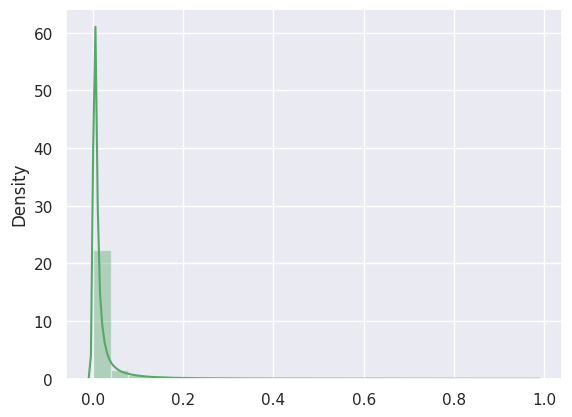

In [7]:
y_pred_test = model.predict_proba(X_test)[:, 1]

from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import pandas as pd

#Plot Data
fig, ax = plt.subplots()
sns.distplot(y_pred_test, bins=25, color="g", ax=ax)
plt.show()

#### Metrics for Optimal Model

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8731349781060925
1% Lift:  22.66429436705027
1% PPV:  36.59311778008679
1% Sensitivity:  22.66429436705027
10% Lift:  6.492277407631738
10% PPV:  10.481731838795243
10% Sensitivity:  64.92277407631738


Text(0.5, 427.9555555555555, 'Predicted label')

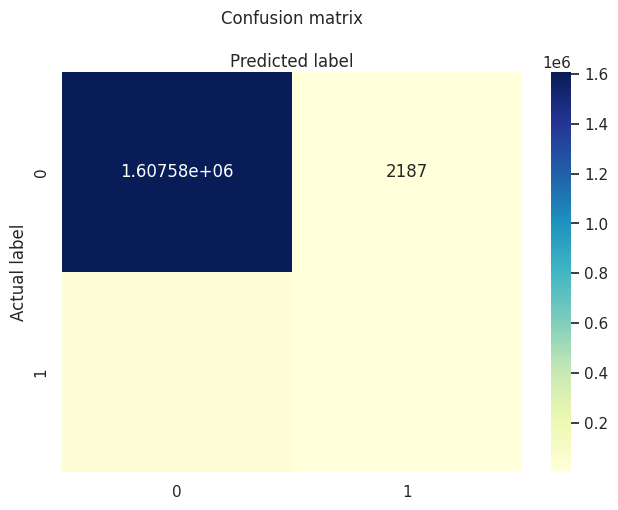

In [10]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [11]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      1.00      0.99   1609769
     with IP       0.55      0.10      0.17     26416

    accuracy                           0.98   1636185
   macro avg       0.77      0.55      0.58   1636185
weighted avg       0.98      0.98      0.98   1636185



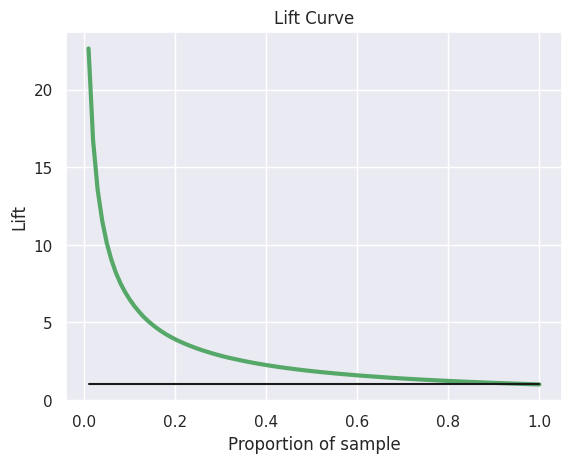

In [12]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(y_test, y_pred_test, step=0.01)


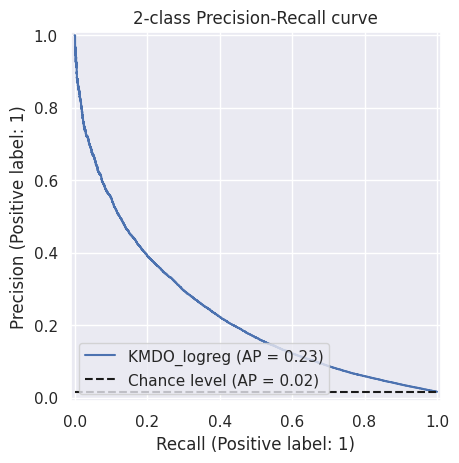

In [13]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [14]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.23465336286989658


In [15]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart= lift_chart(X_test, y_test, model)
lift_chart.to_csv('lift_chart_xgboost.csv')
lift_chart

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.980003,0.295648,5987,16362,1.000009,22.664294,22.664294,1.000009,22.664087
1,0.295643,0.192352,2846,16362,1.000009,10.773773,33.438068,2.000018,16.718881
2,0.192349,0.143838,1901,16362,1.000009,7.196396,40.634464,3.000028,13.544697
3,0.143838,0.114428,1480,16362,1.000009,5.602665,46.237129,4.000037,11.559176
4,0.114426,0.094942,1153,16362,1.000009,4.364779,50.601908,5.000046,10.120289
...,...,...,...,...,...,...,...,...,...
95,0.002225,0.002141,21,16362,1.000009,0.079497,99.757723,95.999963,1.039143
96,0.002141,0.002044,17,16362,1.000009,0.064355,99.822078,96.999972,1.029094
97,0.002044,0.001918,11,16362,1.000009,0.041641,99.863719,97.999982,1.019018
98,0.001918,0.001717,16,16362,1.000009,0.060569,99.924288,98.999991,1.009336


In [16]:
feature_importances = model.get_booster().get_score(importance_type='weight') 
importance_df = pd.DataFrame(feature_importances.items(), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance
print(importance_df)
importance_df.to_csv('importance_df_xgboost.csv')

              Feature  Importance
44             agenbr     33302.0
56              emb58     25677.0
65             emb212     23783.0
62             emb154     23676.0
70             emb238     23475.0
..                ...         ...
32                SCA      1644.0
2   acute_ip_flag_yr1      1627.0
30          paralysis      1498.0
27                MOH      1473.0
25               esrd       868.0

[78 rows x 2 columns]


In [17]:
y_pred = model.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)

threshold = 0.3

y_predict_prob =model.predict_proba(X_test)[:, 1]
y_predict_lab = ((model.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,1599705,10064
1,20530,5886


In [18]:
y_pred.head()

,acute_ip_flag,y_predict_prob,y_predict_class
asdb_member_key,,,
71366923,0,0.023362,0
352154398,0,0.004596,0
440462419,0,0.002741,0
461237047,0,0.059392,0
451362506,0,0.001726,0


In [19]:
y_pred = y_pred.reset_index()
y_pred.head()

,asdb_member_key,acute_ip_flag,y_predict_prob,y_predict_class
0,71366923,0,0.023362,0
1,352154398,0,0.004596,0
2,440462419,0,0.002741,0
3,461237047,0,0.059392,0
4,451362506,0,0.001726,0


In [20]:
from google.cloud import bigquery
import google.auth
from google.auth import impersonated_credentials
credentials, project= google.auth.default()
client = bigquery.Client(credentials=credentials)
output_tbl ="anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_predictions"

job_labels = {"costcenter": 13070, "owner": "palmere1_aetna_com"}
load_config = bigquery.LoadJobConfig(labels=job_labels)
load_job = client.load_table_from_dataframe(
    dataframe = y_pred,
    destination = output_tbl,
    job_config = load_config,
)

print(load_job.result())


LoadJob<project=anbc-hcb-dev, location=US, id=8b17d39a-c347-4c4a-8ee1-7bc0686334c1>


In [ ]:
df_out = pd.merge(y_pred, merged, how = 'left',left_index = True, right_index = True)

In [ ]:
df_out.head()

In [ ]:
df_out.shape

In [ ]:
m0_3 = df_out.loc[df_out['tenure_yr1'].isin([0,1,2,3,])]
m4_8 = df_out.loc[df_out['tenure_yr1'].isin([4,5,6,7,8,])]
m_9_13 = df_out.loc[df_out['tenure_yr1'].isin([9,10,11,12,13,])]

In [ ]:
Foster = df_out[df_out['coa_population_category_Foster'] == 1]

ABD = df_out[(df_out['coa_population_category_DD'] == 1) | 
             (df_out['coa_population_category_ABD Non Dual Non LTSS'] == 1)]

LTSS = df_out[(df_out['coa_population_category_ABD Non Dual LTSS'] == 1) | 
              (df_out['coa_population_category_Dual Elig LTSS'] == 1) |
              (df_out['coa_population_category_Dual Int LTSS'] == 1) |
              (df_out['coa_population_category_LTSS Only'] == 1) ]

Dual = df_out[(df_out['coa_population_category_Dual Elig NonLTSS'] == 1) | 
             (df_out['coa_population_category_Dual Int NonLTSS'] == 1)]

BH = df_out[(df_out['coa_population_category_BH Int SMI'] == 1)]

Adult = df_out[(df_out['coa_population_category_Expansion'] == 1) | 
             ((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] >= 18)) |
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] >= 18))]

Kid = df_out[((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] < 18)) | 
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] < 18)) ]

In [ ]:
plot_lift_curve(Foster['acute_ip_flag_x'], Foster['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(LTSS['acute_ip_flag_x'], LTSS['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Dual['acute_ip_flag_x'], Dual['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(BH['acute_ip_flag_x'], BH['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Adult['acute_ip_flag_x'], Adult['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Kid['acute_ip_flag_x'], Kid['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m0_3['acute_ip_flag_x'], m0_3['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m4_8['acute_ip_flag_x'], m4_8['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m_9_13['acute_ip_flag_x'], m_9_13['y_predict_class'], step=0.01)

In [ ]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

In [ ]:
lift_chart(Foster)

In [ ]:
lift_chart(ABD)

In [ ]:
lift_chart(LTSS)

In [ ]:
lift_chart(Dual)

In [ ]:
lift_chart(BH)

In [ ]:
lift_chart(Adult)

In [ ]:
lift_chart(Kid)

In [ ]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df  

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

In [ ]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

In [ ]:
lift_chart(Foster) 

In [ ]:
lift_chart(ABD)

In [ ]:
lift_chart(LTSS)

In [ ]:
lift_chart(Dual)

In [ ]:
lift_chart(BH)

In [ ]:
lift_chart(Adult)

In [ ]:
lift_chart(Kid)